# Limpieza y Preparación De Datos

En esta parte, el objetivo es comprender mejor los datos y el contexto empresarial, entender en profundidad qué modeliza la variable objetivo y, posteriormente, comenzar a limpiar y preparar los datos para introducirlos en los modelos.

## 1. Importando librerías

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import gc
from pathlib import Path
from sklearn.model_selection import train_test_split

### 1.1 Cargando los datos

In [15]:
datos = Path().resolve().parent / "data"

In [16]:
X = pd.read_csv(datos / "X.csv")
y = pd.read_csv(datos / "target.csv")

Primero un vistazo a los datos

In [17]:
X.head()

,funded_amnt,interest_rate,monthly_payment,grade,emp_title,emp_length,home_ownership_status,annual_income,verification_status,loan_purpose,...,num_inq_in_12mths,mths_since_recent_bankcard_delinq,mths_since_recent_revol_delinq,disbursement_method,loan_term_months,issue_date_month,issue_date_year,region_code,earliest_cr_line_month,earliest_cr_line_year
0,2500,13.56,84.92,C1,Chef,10+ years,RENT,55000.0,Not Verified,debt_consolidation,...,2,NaN,NaN,Cash,36,Dec,2018,1,Apr,2001
1,30000,18.94,777.23,D2,Postmaster,10+ years,MORTGAGE,90000.0,Source Verified,debt_consolidation,...,2,NaN,NaN,Cash,60,Dec,2018,7,Jun,1987
2,5000,17.97,180.69,D1,Administrative,6 years,MORTGAGE,59280.0,Source Verified,debt_consolidation,...,0,NaN,NaN,Cash,36,Dec,2018,4,Apr,2011
3,4000,18.94,146.51,D2,IT Supervisor,10+ years,MORTGAGE,92000.0,Source Verified,debt_consolidation,...,3,NaN,NaN,Cash,36,Dec,2018,9,Feb,2006
4,30000,16.14,731.78,C4,Mechanic,10+ years,MORTGAGE,57250.0,Not Verified,debt_consolidation,...,0,NaN,NaN,Cash,60,Dec,2018,2,Dec,2000


In [18]:
print(f"Tenemos {X.shape[0]} columnas y {X.shape[1]} features")

Tenemos 2139643 columnas y 45 features


Aquí un diccionario de variables para ganar un mayor entendimiento de con que estamos tratando

| Columna | Significado |
|---|---|
| `funded_amnt` | El importe total comprometido en ese préstamo en ese momento |
| `interest_rate` | Tipo de interés del préstamo |
| `monthly_payment` | La cuota mensual que debe pagar el prestatario si se concede el préstamo |
| `grade` | Calificación de C1 a A5, de peor a mejor, respectivamente |
| `emp_title` | El puesto de trabajo indicado por el prestatario al solicitar el préstamo |
| `emp_length` | Antigüedad laboral en años |
| `home_ownership_status` | El estado de propiedad de la vivienda indicado por el prestatario durante el registro |
| `annual_income` | Los ingresos anuales declarados por el propio prestatario durante el registro |
| `verification_status` | Indica si los ingresos fueron verificados por LC, no fueron verificados o si la fuente de ingresos fue verificada |
| `loan_purpose` | Una categoría proporcionada por el prestatario para la solicitud del préstamo |
| `addr_state` | El estado indicado por el prestatario en la solicitud del préstamo |
| `dept_paym_income_ratio` | Una ratio calculada como los pagos mensuales totales de deuda del prestatario, excluyendo la hipoteca y el préstamo solicitado a LC, divididos entre los ingresos mensuales declarados por el propio prestatario |
| `num_30+_delinq_in_2yrs` | El número de incidencias de morosidad con más de 30 días de retraso |
| `num_inq_in_6mths` | El número de consultas de crédito en los últimos 6 meses (excluyendo consultas de auto e hipoteca) |
| `mths_since_last_delinq` | El número de meses desde la última morosidad del prestatario |
| `num_open_credit_lines` | El número de líneas de crédito abiertas en el historial crediticio del prestatario |
| `num_derogatory_pub_rec` | Número de registros públicos derogatorios |
| `total_credit_revolving_bal` | Saldo total en crédito revolving |
| `used_credit_share` | Tasa de utilización de la línea revolving, o la cantidad de crédito que el prestatario está usando en relación con todos sus activos |
| `tot_num_credit_lines` | El número total de líneas de crédito actualmente presentes en el historial crediticio del prestatario |
| `initial_list_status` | El estado inicial de listado del préstamo |
| `num_open_trades_in_6mths` | Número de cuentas abiertas en los últimos 6 meses |
| `num_installment_acc_op_in_12mths` | Número de cuentas de préstamos a plazos abiertas en los últimos 12 meses |
| `num_installment_acc_op_in_24mths` | Número de cuentas de préstamos a plazos abiertas en los últimos 24 meses |
| `mths_since_last_installment_acc_op` | Meses desde la apertura más reciente de una cuenta de préstamo a plazos |
| `num_rev_trades_op_in_12mths` | Número de cuentas revolving abiertas en los últimos 12 meses |
| `num_rev_trades_op_in_24mths` | Número de cuentas revolving abiertas en los últimos 24 meses |
| `max_bal_owed` | Saldo máximo actual debido en todas las cuentas revolving |
| `bal_to_cred_lim` | Ratio saldo/límite de crédito en todas las cuentas |
| `num_inq` | Número de consultas de finanzas personales |
| `num_inq_in_12mths` | Número de consultas de crédito en los últimos 12 meses |
| `mths_since_recent_bankcard_delinq` | Meses desde la morosidad más reciente en tarjeta bancaria |
| `mths_since_recent_revol_delinq` | Meses desde la morosidad revolving más reciente |
| `disbursement_method` | El método por el cual el prestatario recibe su préstamo |
| `loan_term_months` | Duración del préstamo en meses |
| `issue_date_month` | El mes en que se financió el préstamo |
| `issue_date_year` | El año en que se financió el préstamo |
| `region_code` | Código de región, desde "0" en el Noreste (p. ej. Massachusetts, Connecticut) hasta "9" en el Oeste (p. ej. California) |
| `earliest_cr_line_month` | El mes en que se abrió la primera línea de crédito reportada del prestatario |
| `earliest_cr_line_year` | El año en que se abrió la primera línea de crédito reportada del prestatario |

## Variables de desempeño (posteriores a la concesión)

| Columna | Significado |
|---|---|
| `remaining_princ_for_tot_amnt_fund` | Principal pendiente restante respecto al importe total financiado |
| `paym_rec_for_tot_amnt_fund` | Pagos recibidos hasta la fecha respecto al importe total financiado |
| `princ_rec` | Principal recibido hasta la fecha |
| `interest_rec` | Intereses recibidos hasta la fecha |
| `late_fees_rec` | Comisiones por mora recibidas hasta la fecha |

Una vez ya tenemos los datos y que representa cada uno ya podemos empezar a formularnos preguntas acerca del contexto del negocio y que estamos queriendo resolver

Primero puede surgir la pregunta, ¿Qué significa el target default? ¿Qué contamos como default?

Ya que no contamos con una ventana temporal, por ejemplo, default en 24 meses tras la concesión del prestamo

Mirando la documentación de Kaggle indica que ya ha habido un filtrado por Information Value en las variables, por lo que ya partimos de variables que individualmente contienen informacion sobre Default vs No Default

**Contestar segun lo que me digan en el foro**

## 1.2 Mirando NAs

Vamos a empezar a nivel de limpieza de los datos mirando primero los valores nulos en cada feature, con el fin de explorarlos y decidir si son señal y en cierto caso como codificarlos y cuanto sesgo introduciriamos en los datos, o si son ruido o son variables con las que no podemos tratar por mucha falta de información.

Primero vamos a particionar los datos, para en caso de realizar imputaciones o necesitar explorar los datos, no cometer ningun tipo de leakage, al tener mas de 2.000.000 de observaciones, podemos permitirnos un enfoque de conjuntos de entrenamiento, validación y test, cada uno usado respectivamente para.

* Train : Usado para el entrenamiento de los modelos
* Validación : Usado para validar resultados, que no haya overfitting significativo y estimaciones que sean realizadas sin aún llegar a usar test
* Test : Usado al final del todo para estimar el comportamiento de generalización del modelo cuando este recibe informacion nunca vista anteriormente (Reservado unicamente para la evaluación final)

Para saber como hacer la partición antes miraremos la proporcion de default, para saber si estratificar o no

In [32]:
prop = list(y.value_counts())
print(f"La proporción de defaults es de {prop[1]/(prop[0] + prop[1])*100:.2f}%")

La proporción de defaults es de 13.07%


No es un desbalanceo extremo, pero aún así vamos a estratificar para asegurar tenemos ejemplos de ambos casos en todas las particiones

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42,stratify=y) # 15% para test, 85% para val y train
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15/0.85, random_state=42,stratify=y_train) # del 85% total, 

In [42]:
prop_train = np.array(y_train.value_counts())
prop_val = np.array(y_val.value_counts())
prop_test = np.array(y_test.value_counts())
print(f"La proporción de default es en ; Train : {prop_train[1]/np.sum(prop_train)*100:.2f}% , Val : {prop_val[1]/np.sum(prop_val)*100:.2f}% y Test : {prop_test[1]/np.sum(prop_test)*100:.2f}%")

La proporción de default es en ; Train : 13.07% , Val : 13.07% y Test : 13.07%


Una vez hecho esto vamos a comenzar con la limpieza de los datos, haciendo todo en train para evitar cualquier tipo de leakage, pero mirando las columnas de referencia en el dataset entero, para así ver no se ha escapado ningun na a las demás particiones

In [44]:
X.isnull().sum().sort_values(ascending=False)

mths_since_recent_bankcard_delinq     1643502
mths_since_recent_revol_delinq        1433891
mths_since_last_delinq                1090997
mths_since_last_installment_acc_op     905256
bal_to_cred_lim                        865775
num_installment_acc_op_in_12mths       865656
num_installment_acc_op_in_24mths       865656
num_open_trades_in_6mths               865656
num_rev_trades_op_in_12mths            865656
max_bal_owed                           865656
num_rev_trades_op_in_24mths            865656
num_inq                                865656
emp_title                              148527
emp_length                             130346
num_30+_delinq_in_2yrs                      0
addr_state                                  0
dept_paym_income_ratio                      0
verification_status                         0
annual_income                               0
home_ownership_status                       0
grade                                       0
interest_rate                     

Se puede apreciar hay variables con muchos valores faltantes, vamos a tratarlos uno a uno y antes de nada, parar a pensar si el valor nulo es un error u otra forma de decirnos algo.

La variable mths_since_recent_bankcard_delinq es la que mas faltantes representa la cantidad de meses desde la morosidad mas reciente, por lo que un nulo pueded lleva a pensar que en vez de que no lo han apuntado ya que ese es un dato que si queda registrado, que puede indicar que los clientes que presentan ese nulo nunca han entrado en ninguna mora con la tarjeta bancaria, lo cual es un indicador bastante bueno.

Antes de tomar decisiones vamos a explorar esa variable

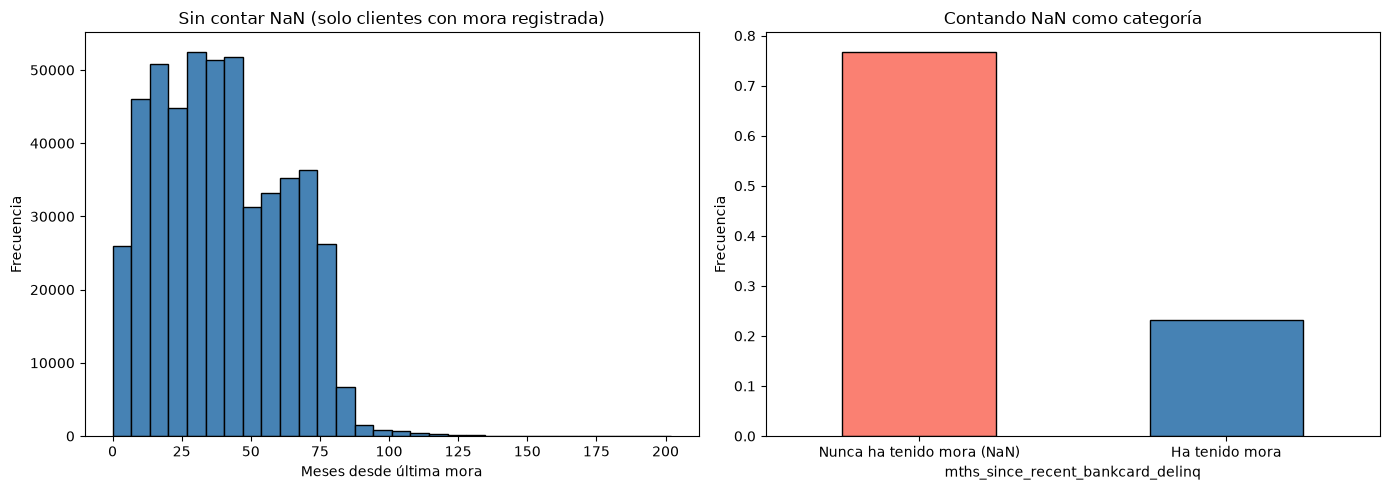

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['mths_since_recent_bankcard_delinq'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Sin contar NaN (solo clientes con mora registrada)')
axes[0].set_xlabel('Meses desde última mora')
axes[0].set_ylabel('Frecuencia')

temp = df['mths_since_recent_bankcard_delinq'].copy()
temp_cat = temp.apply(lambda x: 'Nunca ha tenido mora (NaN)' if pd.isna(x) else 'Ha tenido mora')
temp_cat.value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=['salmon', 'steelblue'], edgecolor='black')
axes[1].set_title('Contando NaN como categoría')
axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
del temp

Podemos apreciar claramente una distribución sesgada, lo cual nos lleva a formular la hipótesis de que la nueva cartera de clientes, la mayoría tienen moras recientes, lo cual no es un buen indicador en este caso, sin embargo recordemos la gran cantidad de faltantes que representan precisamente que nunca han tenido ninguna mora, y vemos precisamente es una gran mayoria aquellos que no han tenido ninguna mora, por lo que ahora tenemos que tomar que decisión tomar sobre como incluir esta información, se podria llevar a cabo:

* Imputar un valor que el modelo sepa reconocer de forma unequívoca como que no ha habido mora
* Imputar y crear un flag binario de que no ha habido mora

Se va a llevar a cabo la segunda opción usando como valor -1, evitando meter valores altos como 999 para evitar el sesgo masivo en las estadísticas de la variable, aparte de crear un flag que indique, no ha tenido moras : 0, ha tenido moras : 1

In [53]:
X_train["bankcard_delinq_flag"] = X_train["mths_since_recent_bankcard_delinq"].notna().astype(int) # Para train
X_train["mths_since_recent_bankcard_delinq"] = X_train["mths_since_recent_bankcard_delinq"].fillna(value=-1)
X_val["bankcard_delinq_flag"] = X_val["mths_since_recent_bankcard_delinq"].notna().astype(int) # Para val
X_val["mths_since_recent_bankcard_delinq"] = X_val["mths_since_recent_bankcard_delinq"].fillna(value=-1)
X_test["bankcard_delinq_flag"] = X_test["mths_since_recent_bankcard_delinq"].notna().astype(int) # Para test
X_test["mths_since_recent_bankcard_delinq"] = X_test["mths_since_recent_bankcard_delinq"].fillna(value=-1)

La proxima variable mths_since_recent_revol_delinq es bastante parecida en naturaleza a la anterior, junto a mths_since_last_delinq y mths_since_last_installment_acc_op

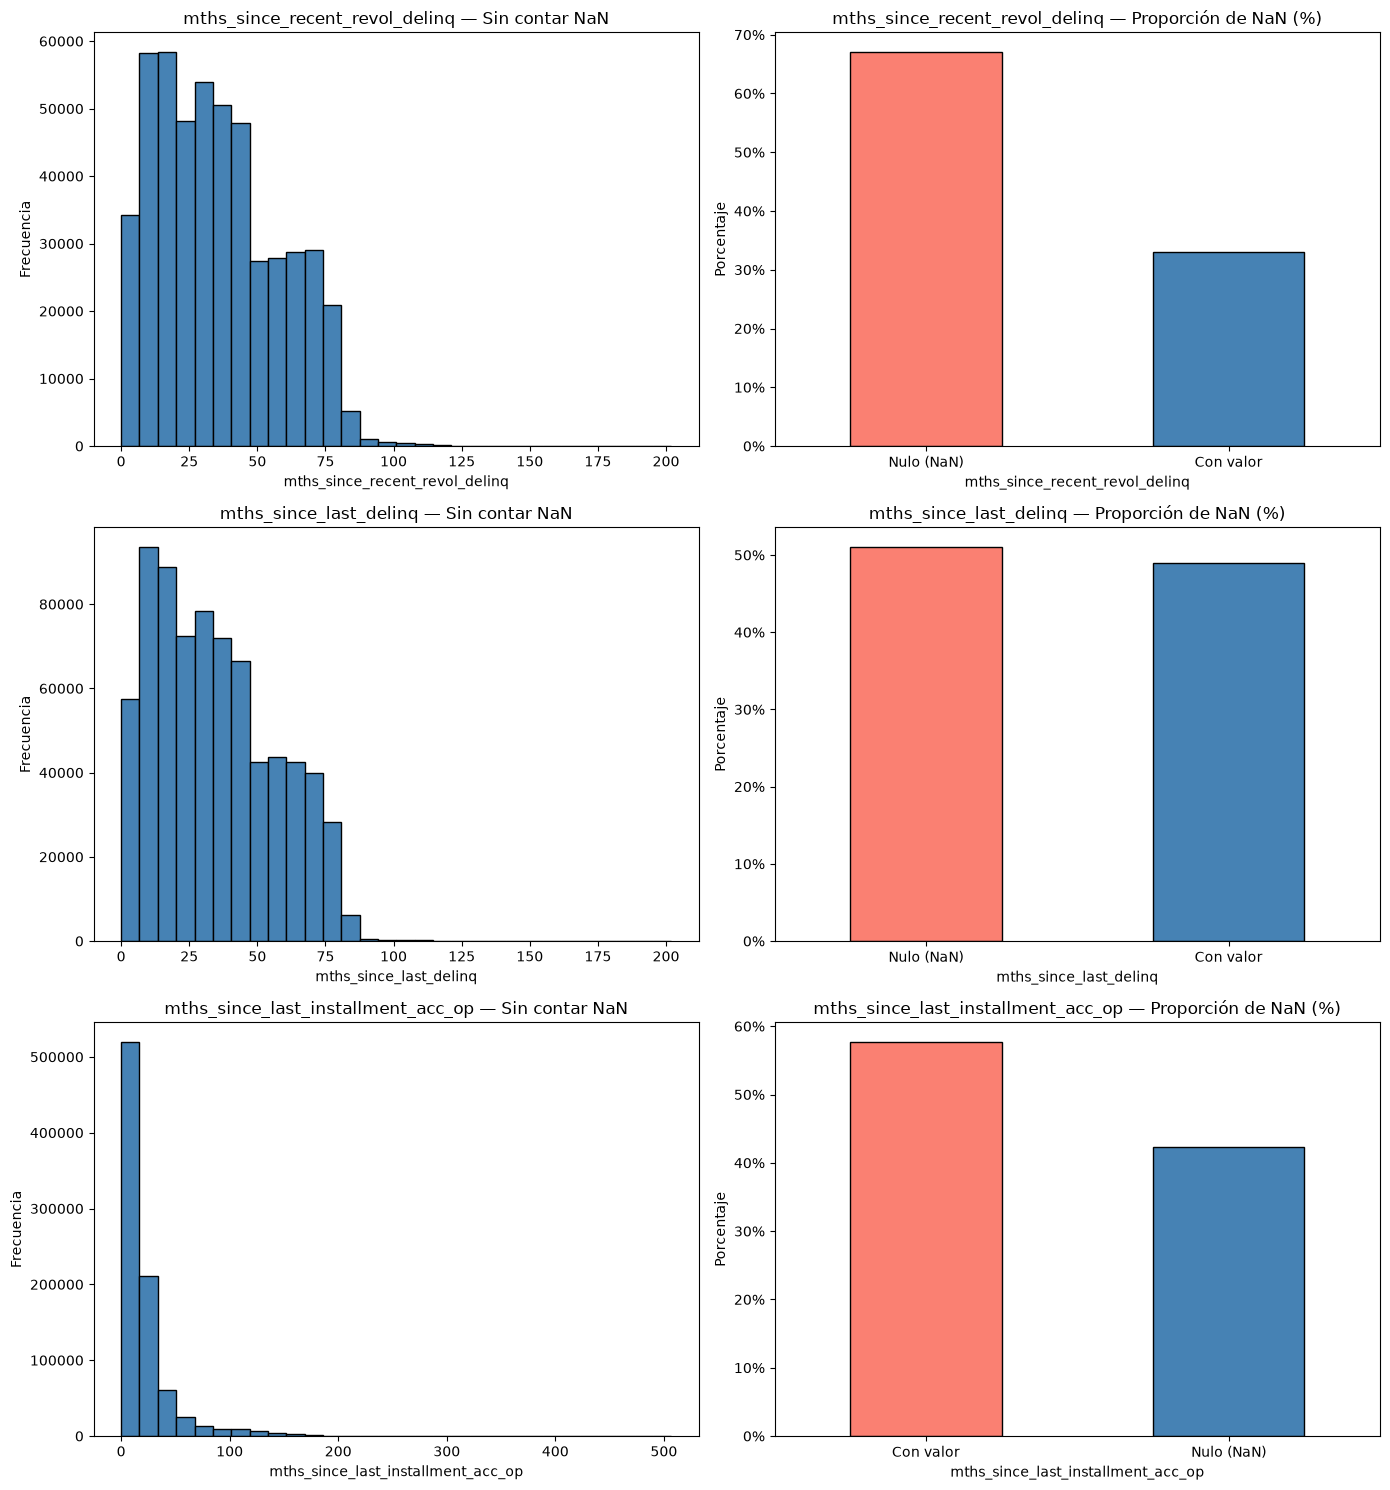

In [61]:
variables = ['mths_since_recent_revol_delinq', 'mths_since_last_delinq', 'mths_since_last_installment_acc_op']

fig, axes = plt.subplots(len(variables), 2, figsize=(14, 5 * len(variables)))

for i, var in enumerate(variables):
    # Columna 1: histograma sin contar NaN
    axes[i, 0].hist(X_train[var].dropna(), bins=30, color='steelblue', edgecolor='black')
    axes[i, 0].set_title(f'{var} — Sin contar NaN')
    axes[i, 0].set_xlabel(var)
    axes[i, 0].set_ylabel('Frecuencia')

    # Columna 2: proporción con/sin NaN
    temp_cat = X_train[var].apply(lambda x: 'Nulo (NaN)' if pd.isna(x) else 'Con valor')
    (temp_cat.value_counts(normalize=True) * 100).plot(
        kind='bar', ax=axes[i, 1], color=['salmon', 'steelblue'], edgecolor='black'
    )
    axes[i, 1].set_title(f'{var} — Proporción de NaN (%)')
    axes[i, 1].set_ylabel('Porcentaje')
    axes[i, 1].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

En los tres casos se ve son distribuciones claramente sesgadas, ahora, vamos a ordenar las conclusiones para cada variable :
* mths_since_recent_revol_delinq : Vemos algo muy parecido a la variable de meses desde la última morosidad en la tarjeta de cŕedito y usaremos la misma técnica, ya que no tiene sentido no se registre una incidencia si no que el faltante indique que no ha habido mora por parte de ese cliente, al menos en la basta mayoría de los casos
* mths_since_last_delinq : Mismo razonamiento que las variables anteriores, sin embargo aquí vemos que la proporción entre tener moras o no no es tan dispar, también surge la pregunta de cuanta información ya aporta esta variable al considerar moras de cualquier tipo del prestatario, que sería repetida en las dos variables anteriores. y cuantificarla para determinar si es redundante o no.
* mths_since_last_installment_acc_op : En esta su naturaleza cambia a pesar de tener nombre parecido a las demás, el nulo indica que el cliente nunca ha abierto una cuenta de prestamos a plazos, imputaremos con flag -1 y crearemos flag de que nunca ha abierto cuenta

In [62]:
# Para Train
X_train["revol_delinq_flag"] = X_train["mths_since_recent_revol_delinq"].notna().astype(int)
X_train["mths_since_recent_revol_delinq"] = X_train["mths_since_recent_revol_delinq"].fillna(value=-1)
X_train["delinq_flag"] = X_train["mths_since_last_delinq"].notna().astype(int)
X_train["mths_since_last_delinq"] = X_train["mths_since_last_delinq"].fillna(value=-1)
X_train["no_installment_acc_flag"] = X_train["mths_since_last_installment_acc_op"].notna().astype(int)
X_train["mths_since_last_installment_acc_op"] = X_train["mths_since_last_installment_acc_op"].fillna(value=-1)

# Para Val
X_val["revol_delinq_flag"] = X_val["mths_since_recent_revol_delinq"].notna().astype(int)
X_val["mths_since_recent_revol_delinq"] = X_val["mths_since_recent_revol_delinq"].fillna(value=-1)
X_val["delinq_flag"] = X_val["mths_since_last_delinq"].notna().astype(int)
X_val["mths_since_last_delinq"] = X_val["mths_since_last_delinq"].fillna(value=-1)
X_val["no_installment_acc_flag"] = X_val["mths_since_last_installment_acc_op"].notna().astype(int)
X_val["mths_since_last_installment_acc_op"] = X_val["mths_since_last_installment_acc_op"].fillna(value=-1)

# Para Test
X_test["revol_delinq_flag"] = X_test["mths_since_recent_revol_delinq"].notna().astype(int)
X_test["mths_since_recent_revol_delinq"] = X_test["mths_since_recent_revol_delinq"].fillna(value=-1)
X_test["delinq_flag"] = X_test["mths_since_last_delinq"].notna().astype(int)
X_test["mths_since_last_delinq"] = X_test["mths_since_last_delinq"].fillna(value=-1)
X_test["no_installment_acc_flag"] = X_test["mths_since_last_installment_acc_op"].notna().astype(int)
X_test["mths_since_last_installment_acc_op"] = X_test["mths_since_last_installment_acc_op"].fillna(value=-1)


Ahora es el turno de bal_to_cred_lim

In [68]:
X_train["bal_to_cred_lim"].describe()

count    891560.000000
mean         57.073457
std          20.855174
min           0.000000
25%          43.000000
50%          58.000000
75%          72.000000
max         239.000000
Name: bal_to_cred_lim, dtype: float64

[]

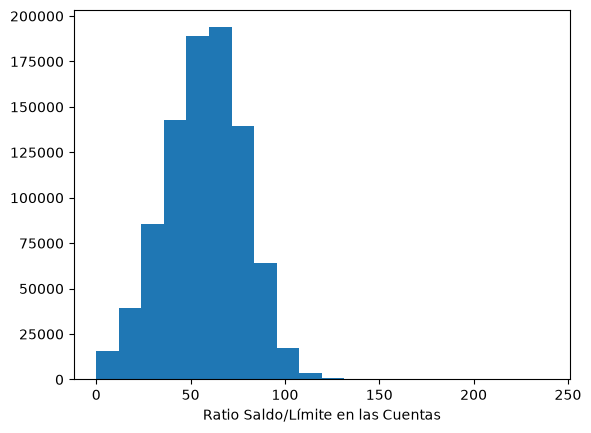

In [69]:
plt.hist(X_train["bal_to_cred_lim"],bins=20)
plt.xlabel("Ratio Saldo/Límite en las Cuentas")
plt.plot()

Vemos sigue una forma de campana, aún así volviendo a el tratamiento de los nulos, dado que proviene de la cantidad de saldo y el límite, podemos intuir que para que sea un valor nulo, o bien no tenía un límite fijado en su tarjeta de crédito o bien no tiene una cuenta de crédito activa, pero esto de momento es una hipótesis y no una realidad, aún no la hemos probado.

Dado que su cantidad de nulos se parece mucho a el numero de nulos del resto de variables, podriamos hipotetizar que pueden tener relacion, vamos a mirar eso justamente.

In [74]:
cols = [
    "bal_to_cred_lim",
    "num_installment_acc_op_in_12mths",
    "num_installment_acc_op_in_24mths",
    "num_open_trades_in_6mths",
    "num_rev_trades_op_in_12mths",
    "max_bal_owed",
    "num_rev_trades_op_in_24mths",
    "num_inq"
]

X_train[cols].isna().all(axis=1).value_counts(normalize=True)

False    0.595325
True     0.404675
Name: proportion, dtype: float64

No parece que haya ningún patrón, vamos a nvestigar mezclando con la variable de cantidad total revolvente, para ver si dentro de esta variable vemos diferencias entre grupos

In [ ]:
df.groupby(df[cols].isna().all(axis=1))["total_credit_revolving_bal"].describe()

,count,mean,std,min,25%,50%,75%,max
False,1273987.0,16481.976798,23271.566637,0.0,5676.0,10954.0,19773.0,2559552.0
True,865656.0,16908.212264,22420.077898,0.0,6448.0,11876.0,20818.0,2904836.0


Vamos a estudiar dentro de varias variable si vemos diferencias entre grupos

In [85]:
X_train["bal_missing"] = X_train["bal_to_cred_lim"].isna()

pd.crosstab(
    X_train["bal_missing"],
    X_train["home_ownership_status"],
    normalize="index"
)

home_ownership_status,MORTGAGE,OTHER,OWN,RENT
bal_missing,,,,
False,0.469654,0.000794,0.123038,0.406513
True,0.499420,0.000259,0.098129,0.402191


In [86]:
pd.crosstab(
    X_train["bal_missing"],
    X_train["grade"],
    normalize="index"
)

grade,A1,A2,A3,A4,A5,B1,B2,B3,B4,B5,...,F1,F2,F3,F4,F5,G1,G2,G3,G4,G5
bal_missing,,,,,,,,,,,,,,,,,,,,,
False,0.047751,0.033879,0.036203,0.044500,0.046533,0.058565,0.056324,0.055866,0.062335,0.066894,...,0.004478,0.002920,0.002418,0.001959,0.001801,0.001484,0.000983,0.000793,0.000781,0.000708
True,0.025601,0.025320,0.026190,0.039039,0.050339,0.050628,0.054920,0.063762,0.062758,0.054646,...,0.008222,0.006128,0.005046,0.003929,0.002889,0.002115,0.001590,0.001095,0.000754,0.000690


In [87]:
pd.crosstab(
    X_train["bal_missing"],
    X_train["loan_purpose"],
    normalize="index"
)

loan_purpose,car,credit_card,debt_consolidation,educational,home_improvement,house,major_purchase,medical,moving,other,renewable_energy,small_business,vacation,wedding
bal_missing,,,,,,,,,,,,,,
False,0.011243,0.230097,0.545290,0.000001,0.070463,0.007821,0.024499,0.013266,0.007103,0.070875,0.000649,0.010593,0.008096,0.000004
True,0.010007,0.231929,0.591395,0.000515,0.058305,0.004221,0.019596,0.009596,0.006138,0.047927,0.000671,0.011676,0.005347,0.002676


In [88]:
bal_missing = X_train["bal_to_cred_lim"].isna()

y_train.groupby(bal_missing).mean()

,y
bal_to_cred_lim,
False,0.101294
True,0.174023


In [89]:
tmp = (
    X_train
    .assign(bal_missing=X_train["bal_to_cred_lim"].isna())
    .groupby("issue_date_year")["bal_missing"]
    .mean()
)

tmp

issue_date_year
2007    1.000000
2008    1.000000
2009    1.000000
2010    1.000000
2011    1.000000
2012    1.000000
2013    1.000000
2014    1.000000
2015    0.949587
2016    0.000171
2017    0.000103
2018    0.000154
Name: bal_missing, dtype: float64

Aquí ya podemos apreciar algo clave, esa información faltante es perteneciente en su mayoría y en años enteros, a años pasados, con lo que las diferencias entre grupos tienen un componente temporal, mas que el propio valor faltante del ratio entre balance y limite, vamos a mirar esto mismo en el resto de variables, en las que se ha hipotetizado que podrian formar parte de un bloque de missings

In [92]:
missing_cols = [
    "bal_to_cred_lim",
    "num_installment_acc_op_in_12mths",
    "num_installment_acc_op_in_24mths",
    "num_open_trades_in_6mths",
    "num_rev_trades_op_in_12mths",
    "max_bal_owed",
    "num_rev_trades_op_in_24mths",
    "num_inq"
]

missing_rate_by_year = (
    X_train
    .groupby("issue_date_year")[missing_cols]
    .apply(lambda x: x.isna().mean())
)

missing_rate_by_year

,bal_to_cred_lim,num_installment_acc_op_in_12mths,num_installment_acc_op_in_24mths,num_open_trades_in_6mths,num_rev_trades_op_in_12mths,max_bal_owed,num_rev_trades_op_in_24mths,num_inq
issue_date_year,,,,,,,,
2007,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2008,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2009,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2010,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2011,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2012,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2013,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2014,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2015,0.949587,0.949587,0.949587,0.949587,0.949587,0.949587,0.949587,0.949587


In [93]:
missing_matrix = X_train[missing_cols].isna()

same_missing_pattern = missing_matrix.nunique(axis=1)

same_missing_pattern.value_counts()

1    1497662
2         87
Name: count, dtype: int64

Con esto ya podemos ver que respecto a los missings no solo es cuestión temporal mas que de señal, además que las tasas son casi idénticas, por lo que lleva a pensar podría ser información que en esos años no era recabada y no se tenía en cuenta, ya que vemos como en cuestion de un año la tasa se desploma a 0 practicamente.
A su vez vemos que dentro de esas variables la basta mayoría su valor coincide. Vamos a estudiar aquellas donde esto se rompe

In [95]:
mixed_patterns = (
    X_train.loc[mixed_rows.index, missing_cols]
    .isna()
    .value_counts()
)

mixed_patterns

bal_to_cred_lim  num_installment_acc_op_in_12mths  num_installment_acc_op_in_24mths  num_open_trades_in_6mths  num_rev_trades_op_in_12mths  max_bal_owed  num_rev_trades_op_in_24mths  num_inq
True             False                             False                             False                     False                        False         False                        False      87
Name: count, dtype: int64

Vemos que la unica en la que se rompe el patron es en bal_to_cred_lim, por lo que vamos a investigarlas y ver en que años y mes se producieron, ya que tenemos bastante evidencia como para pensar es un problema relacionado con la dimensión temporal

In [96]:
extra_bal_missing = X_train[
    X_train["bal_to_cred_lim"].isna()
    & X_train[missing_cols[1:]].notna().all(axis=1)
]

extra_bal_missing["issue_date_year"].value_counts().sort_index()

issue_date_year
2016    12
2017    29
2018    46
Name: count, dtype: int64

In [98]:
extra_bal_missing["issue_date_month"].value_counts().sort_index()

issue_date_month
Apr     6
Aug     9
Dec    10
Feb     3
Jan     3
Jul     9
Jun     7
Mar     8
May     5
Nov    10
Oct     6
Sep    11
Name: count, dtype: int64

In [97]:
extra_bal_missing[
    ["issue_date_year", "issue_date_month"]
].sort_values(
    ["issue_date_year", "issue_date_month"]
)

,issue_date_year,issue_date_month
467796,2016,Aug
475273,2016,Aug
757215,2016,Dec
713557,2016,Feb
500112,2016,Jul
...,...,...
140919,2018,Sep
125959,2018,Sep
123914,2018,Sep
132328,2018,Sep


Vemos estas últimas no parecen seguit ningun patron temporal, dado que son solo 87 es un número despreciable dado el alto tamaño de muestra.

Para concluir con esta variable tenemos el problema de que en años enteros falta esta información por lo que imputarla introduciría muchísimo sesgo al modelo por lo que no es viable, y dada que esta es una variable que como hemos visto ya si se toma y estaría para usarla, podriamos :
* Reducir y usar solo datos de 2016-2018 donde no hay nulos a secas o son un número muy reducido, pero esto reduciría la muestra mucho eliminando la mayoría de años
* Eliminar las variables y continuar incluyendo todos los años de la muestra
* Crear dos datasets, donde en uno conservamos todos los años y otro solo del 2016 al 2018

In [103]:
n_total = len(X_train)

n_2016 = (X_train["issue_date_year"] >= 2016).sum()

print(f"Total: {n_total:,}")
print(f"Desde 2016: {n_2016:,}")
print(f"Se conserva: {n_2016/n_total:.2%}")
print(f"Se pierde: {1 - n_2016/n_total:.2%}")

Total: 1,497,749
Desde 2016: 876,865
Se conserva: 58.55%
Se pierde: 41.45%


In [110]:
X_train = X_train.drop(columns="bal_missing")

Conservariamos una gran parte de la muestra, a su vez nos enfocariamos en informacion mas actual, ya que desde 2007 ha cambiado la situación, sin ir más lejos la crisis del 2008, y usar informacion mas reciente puede ser más útil dado que es mas cercana al contexto actual

In [112]:
mask_train = X_train["issue_date_year"] >= 2016
mask_val = X_val["issue_date_year"] >= 2016
mask_test = X_test["issue_date_year"] >= 2016

X_train = X_train.loc[mask_train]
y_train = y_train.loc[mask_train]
X_val = X_val.loc[mask_val]
y_val = y_val.loc[mask_val]
X_test = X_test.loc[mask_test]
y_test = y_test.loc[mask_test]

In [113]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(876865, 49) (876865, 1)
(187824, 49) (187824, 1)
(188153, 49) (188153, 1)


In [119]:
X_train.isnull().sum().sort_values(ascending=False)

emp_title                             67951
emp_length                            59865
bal_to_cred_lim                         126
num_open_trades_in_6mths                 39
num_inq                                  39
num_installment_acc_op_in_24mths         39
num_rev_trades_op_in_24mths              39
num_rev_trades_op_in_12mths              39
num_installment_acc_op_in_12mths         39
max_bal_owed                             39
funded_amnt                               0
monthly_payment                           0
interest_rate                             0
grade                                     0
home_ownership_status                     0
annual_income                             0
verification_status                       0
num_derogatory_pub_rec                    0
num_open_credit_lines                     0
mths_since_last_delinq                    0
num_inq_in_6mths                          0
num_30+_delinq_in_2yrs                    0
dept_paym_income_ratio          

Continuemos con emp_lenth y emp_title

In [123]:
X_train["emp_title"].unique()

<ArrowStringArray>
[                                      nan,
                            'Pediatrician',
           'Member Service Representative',
                    'Director of Security',
                            'Poker dealer',
               'Figure skating instructor',
                             'Supervisor ',
                       'District Director',
                                  'welder',
                'Senior Analyst (trading)',
 ...
     'Senior physician compliance auditor',
                      'DIESEL TECHNICIAN ',
                         'User researcher',
                                'ap clerk',
             'Resource Efficiency Manager',
                 'Driver / Nursery Worker',
 'Principal Customer Service Coordinator ',
    'IT Support Assistant (Helpdesk Tech)',
                        'DIETARY DIRECTOR',
                       'INVESTIGATOR AIDE']
Length: 201323, dtype: str

Tiene muchisima cardinalidad por lo que un one hot encoding no es viable bajo ningun concepto, y agrupar bajo un rango por ejemplo White Colla Job/ Blue Collar Job se hace imposible si tenemos que tratar 200.000 titulos de trabajo distintos, por lo que la decisión es de momento dejarla fuera, ya que transformarla para que pueda ser introducida en modelos es inviable a no ser que busquemos alguna técnica de NLP o algo por el estilo, y ya tenemos informacion relacionada como el sueldo, experiencia laboral y demás que ya dan la información valiosa, ya que por sí mismo un trabajo u otro no cambia tu riesgo de default, sino aquello que te da el trabajo, asi que teniendo ya esa información se puede argumentar esta información ya está contenida en nuestro dataset, además que en producción puede llegar alguien que no tenga ninguno de estos trabajos y se nos rompa en ese caso el modelo

In [125]:
X_train.drop("emp_title",axis=1,inplace=True)
X_val.drop("emp_title",axis=1,inplace=True)
X_test.drop("emp_title",axis=1,inplace=True)